# 基于互相关分析推断交通图边方向（多日投票版）

- 使用原始时间序列（不做平均聚合）
- 多个日期分别计算互相关
- 投票得出最终方向

## 1. 环境配置

In [1]:
import pandas as pd
import numpy as np
from scipy import signal
from collections import Counter
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "../output/edge_inference"
META_DIR = "../d03_meta_processed"
DATA_DIR = "/data/yuzhang_fei/PEMS/PEMSD3_2025"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("库加载完成！")

库加载完成！


## 2. 加载数据

In [2]:
# 加载交通流数据
print("加载交通流数据...")
flow_df = pd.read_csv(
    os.path.join(DATA_DIR, 'pems_5min_merged.csv'),
    dtype={'Station': str},
    parse_dates=['Timestamp']
)
print(f"交通流数据: {len(flow_df):,} 行")

# 加载 ML 传感器元数据
print("\n加载传感器元数据...")
meta_df = pd.read_csv(
    os.path.join(META_DIR, 'sensors_common_2025.csv'),
    dtype={'ID': str, 'Fwy': str}
)
ml_meta = meta_df[meta_df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_meta)}")

# 筛选 ML 传感器的流量数据
ml_ids = set(ml_meta['ID'])
flow_ml = flow_df[flow_df['Station'].isin(ml_ids)].copy()
print(f"ML 流量数据: {len(flow_ml):,} 行")

加载交通流数据...
交通流数据: 196,416,876 行

加载传感器元数据...
ML 传感器数: 854
ML 流量数据: 88,879,188 行


In [3]:
# 提取日期信息
flow_ml['Date'] = flow_ml['Timestamp'].dt.date
flow_ml['DayOfWeek'] = flow_ml['Timestamp'].dt.dayofweek  # 0=Mon
flow_ml['TimeSlot'] = flow_ml['Timestamp'].dt.hour * 12 + flow_ml['Timestamp'].dt.minute // 5

# 查看可用日期
available_dates = sorted(flow_ml['Date'].unique())
print(f"可用日期数: {len(available_dates)}")
print(f"日期范围: {available_dates[0]} ~ {available_dates[-1]}")

可用日期数: 363
日期范围: 2025-01-01 ~ 2025-12-31


## 3. 选择用于分析的日期

In [4]:
# 选择策略：每个月选取一个工作日（周二，避免周一效应）
# 也可以手动指定日期列表

def select_analysis_dates(flow_ml, day_of_week=1, max_dates=12):
    """
    选择用于分析的日期
    day_of_week: 0=Mon, 1=Tue, ..., 6=Sun
    """
    # 筛选指定星期几
    dates_df = flow_ml[['Date', 'DayOfWeek']].drop_duplicates()
    target_dates = dates_df[dates_df['DayOfWeek'] == day_of_week]['Date'].tolist()
    target_dates = sorted(target_dates)
    
    # 均匀采样
    if len(target_dates) > max_dates:
        step = len(target_dates) // max_dates
        selected = target_dates[::step][:max_dates]
    else:
        selected = target_dates
    
    return selected


# 选择周二的日期
# selected_dates = select_analysis_dates(flow_ml, day_of_week=1, max_dates=12)
# print(f"选择的分析日期 ({len(selected_dates)} 个):")
# for d in selected_dates:
#     print(f"  {d}")

In [5]:
#也可以手动指定日期
selected_dates = [
    pd.Timestamp('2025-01-06').date(),
    pd.Timestamp('2025-01-07').date(),
    pd.Timestamp('2025-01-08').date(),
    pd.Timestamp('2025-01-09').date(),
    pd.Timestamp('2025-01-10').date(),
    pd.Timestamp('2025-01-11').date(),  
    pd.Timestamp('2025-01-12').date(),
]

## 4. 构建相邻传感器对

In [6]:
def build_adjacent_pairs(ml_meta):
    """
    构建相邻传感器对，确定理论方向
    """
    pairs = []
    
    for (fwy, direction), group in ml_meta.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]
            node2 = sorted_group.iloc[i + 1]
            
            distance = node2['Abs_PM'] - node1['Abs_PM']
            
            # 理论方向
            if direction in ['N', 'E']:
                source, target = node1['ID'], node2['ID']
            else:
                source, target = node2['ID'], node1['ID']
            
            pairs.append({
                'Node1': node1['ID'],
                'Node2': node2['ID'],
                'Fwy': fwy,
                'Dir': direction,
                'Distance': distance,
                'True_Source': source,
                'True_Target': target
            })
    
    return pd.DataFrame(pairs)


pairs_df = build_adjacent_pairs(ml_meta)
print(f"相邻传感器对数: {len(pairs_df)}")

相邻传感器对数: 814


## 5. 提取单日序列

In [7]:
def get_daily_series(flow_ml, station, date, metric='Total_Flow'):
    """
    获取某站点某天的原始时间序列（288点）
    """
    mask = (flow_ml['Station'] == station) & (flow_ml['Date'] == date)
    day_data = flow_ml[mask].sort_values('TimeSlot')
    
    if len(day_data) == 0:
        return None
    
    # 构建完整的 288 点序列（缺失填 NaN）
    series = np.full(288, np.nan)
    for _, row in day_data.iterrows():
        slot = int(row['TimeSlot'])
        if 0 <= slot < 288:
            series[slot] = row[metric]
    
    return series


# 测试
test_station = pairs_df.iloc[0]['Node1']
test_date = selected_dates[0]
test_series = get_daily_series(flow_ml, test_station, test_date)
print(f"测试序列 (Station={test_station}, Date={test_date}):")
print(f"  长度: {len(test_series)}")
print(f"  非空值: {np.sum(~np.isnan(test_series))}")
print(f"  前10个值: {test_series[:10]}")

测试序列 (Station=3034105, Date=2025-01-06):
  长度: 288
  非空值: 288
  前10个值: [ 0.  0. 16.  4.  0.  0.  0.  0.  0.  0.]


## 6a. 互相关计算

In [8]:
def compute_lag(series1, series2, max_lag=12):
    """
    计算两个序列的最优滞后
    
    返回:
    - lag: 最优滞后（正值表示 series1 领先）
    - corr: 最大相关系数
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    # 去除 NaN（只保留两者都有值的点）
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    if len(s1) < 50:  # 有效数据太少
        return np.nan, np.nan
    
    # 检查方差
    if np.std(s1) < 1e-6 or np.std(s2) < 1e-6:
        return np.nan, np.nan
    
    # 标准化
    s1 = (s1 - np.mean(s1)) / np.std(s1)
    s2 = (s2 - np.mean(s2)) / np.std(s2)
    
    # 计算互相关
    correlation = signal.correlate(s2, s1, mode='full')
    lags = signal.correlation_lags(len(s2), len(s1), mode='full')
    
    # 限制滞后范围
    valid_mask = (lags >= -max_lag) & (lags <= max_lag)
    correlation = correlation[valid_mask]
    lags = lags[valid_mask]
    
    # 归一化
    correlation = correlation / len(s1)
    
    # 找最大相关
    max_idx = np.argmax(np.abs(correlation))  # 用绝对值找峰值
    best_lag = lags[max_idx]
    best_corr = correlation[max_idx]
    
    return best_lag, best_corr

In [9]:
def analyze_pair_single_day(flow_ml, node1, node2, date, metric='Total_Flow', max_lag=12):
    """
    分析一对传感器在单日的滞后
    """
    s1 = get_daily_series(flow_ml, node1, date, metric)
    s2 = get_daily_series(flow_ml, node2, date, metric)
    
    lag, corr = compute_lag(s1, s2, max_lag)
    return lag, corr


def analyze_pair_multi_day(flow_ml, node1, node2, dates, metric='Total_Flow', max_lag=12):
    """
    分析一对传感器在多个日期的滞后，投票得出方向
    """
    lags = []
    corrs = []
    
    for date in dates:
        lag, corr = analyze_pair_single_day(flow_ml, node1, node2, date, metric, max_lag)
        lags.append(lag)
        corrs.append(corr)
    
    # 有效结果
    valid_lags = [l for l in lags if not np.isnan(l)]
    
    if len(valid_lags) == 0:
        return lags, corrs, np.nan, 'unknown'
    
    # 投票：统计方向
    votes = []
    for l in valid_lags:
        if l > 0:
            votes.append(node1)  # node1 领先
        elif l < 0:
            votes.append(node2)  # node2 领先
        # l == 0 不投票
    
    if len(votes) == 0:
        return lags, corrs, 0, 'uncertain'
    
    # 多数投票
    vote_count = Counter(votes)
    pred_source, count = vote_count.most_common(1)[0]
    
    # 计算中位数滞后
    median_lag = np.median(valid_lags)
    
    # 如果投票太分散，标记为不确定
    if count < len(votes) * 0.6:  # 少于60%的一致性
        pred_source = 'uncertain'
    
    return lags, corrs, median_lag, pred_source

## 6b. 傅立叶相位差计算

In [10]:
# ============================================================
# 傅立叶相位差方法 - 插入到 "## 6. 互相关计算" 之后
# 建议新建一个 section: "## 6b. 傅立叶相位差计算"
# ============================================================

## 6b. 傅立叶相位差计算

def compute_lag_fft(series1, series2, fs=12, target_periods=[288, 144, 96]):
    """
    使用傅立叶相位差计算时间延迟
    
    参数:
    - series1, series2: 时间序列
    - fs: 采样频率（每小时采样数，5分钟间隔=12）
    - target_periods: 关注的周期（以采样点数计）
        - 288: 日周期（24h）
        - 144: 半日周期（12h）
        - 96: 8小时周期
    
    返回:
    - lag: 时间延迟（采样点数），正值表示 series1 领先
    - coherence: 相干性（0-1）
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    n = len(s1)
    if n < 50:
        return np.nan, np.nan
    
    # 检查方差
    if np.std(s1) < 1e-6 or np.std(s2) < 1e-6:
        return np.nan, np.nan
    
    # 去均值
    s1 = s1 - np.mean(s1)
    s2 = s2 - np.mean(s2)
    
    # FFT
    fft1 = np.fft.fft(s1)
    fft2 = np.fft.fft(s2)
    freqs = np.fft.fftfreq(n)
    
    # 交叉功率谱
    cross_spectrum = fft1 * np.conj(fft2)
    
    # 自功率谱（用于计算相干性）
    power1 = np.abs(fft1) ** 2
    power2 = np.abs(fft2) ** 2
    
    # 在目标周期上计算相位差和相干性
    phase_diffs = []
    coherences = []
    weights = []
    
    for period in target_periods:
        if period > n:
            continue
        
        # 找到对应频率的索引
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs[:n//2] - target_freq))
        
        if freq_idx == 0:
            continue
        
        # 相位差
        phase_diff = np.angle(cross_spectrum[freq_idx])
        
        # 相干性
        coh = np.abs(cross_spectrum[freq_idx]) ** 2 / (power1[freq_idx] * power2[freq_idx] + 1e-10)
        coh = np.sqrt(coh)
        
        # 能量权重
        energy = np.abs(cross_spectrum[freq_idx])
        
        if coh > 0.3:  # 只考虑相干性较高的频率
            phase_diffs.append(phase_diff)
            coherences.append(coh)
            weights.append(energy * coh)
    
    if len(phase_diffs) == 0:
        return np.nan, np.nan
    
    # 加权平均相位差
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    avg_phase_diff = np.sum(np.array(phase_diffs) * weights)
    avg_coherence = np.sum(np.array(coherences) * weights)
    
    # 相位差转时间延迟
    # 使用主导周期（日周期）来转换
    dominant_period = target_periods[0]  # 288 点 = 24小时
    lag = avg_phase_diff / (2 * np.pi) * dominant_period
    
    # 限制在合理范围内（±半个周期）
    if lag > dominant_period / 2:
        lag -= dominant_period
    elif lag < -dominant_period / 2:
        lag += dominant_period
    
    return lag, avg_coherence


def analyze_pair_fft_single_day(flow_ml, node1, node2, date, metric='Total_Flow'):
    """
    使用FFT分析单日的时间延迟
    """
    s1 = get_daily_series(flow_ml, node1, date, metric)
    s2 = get_daily_series(flow_ml, node2, date, metric)
    
    lag, coh = compute_lag_fft(s1, s2)
    return lag, coh


def analyze_pair_fft_multi_day(flow_ml, node1, node2, dates, metric='Total_Flow'):
    """
    多日FFT分析，投票得出方向
    """
    lags = []
    cohs = []
    
    for date in dates:
        lag, coh = analyze_pair_fft_single_day(flow_ml, node1, node2, date, metric)
        lags.append(lag)
        cohs.append(coh)
    
    # 有效结果
    valid_lags = [l for l, c in zip(lags, cohs) if not np.isnan(l) and c > 0.3]
    
    if len(valid_lags) == 0:
        return lags, cohs, np.nan, 'unknown'
    
    # 投票
    votes = []
    for l in valid_lags:
        if l > 0.5:  # 阈值：半个时间步
            votes.append(node1)
        elif l < -0.5:
            votes.append(node2)
    
    if len(votes) == 0:
        return lags, cohs, 0, 'uncertain'
    
    vote_count = Counter(votes)
    pred_source, count = vote_count.most_common(1)[0]
    
    median_lag = np.median(valid_lags)
    
    if count < len(votes) * 0.6:
        pred_source = 'uncertain'
    
    return lags, cohs, median_lag, pred_source


# ============================================================
# 可视化单边的FFT分析 - 可选添加
# ============================================================

def visualize_edge_fft(flow_ml, node1, node2, start_date, end_date, metric='Total_Flow', figsize=(14, 12)):
    """
    可视化一条边的傅立叶分析
    """
    # 转换日期
    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date).date()
    if isinstance(end_date, str):
        end_date = pd.to_datetime(end_date).date()
    
    # 筛选数据
    mask1 = (flow_ml['Station'] == node1) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    mask2 = (flow_ml['Station'] == node2) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    
    df1 = flow_ml[mask1][['Timestamp', metric]].set_index('Timestamp').sort_index()
    df2 = flow_ml[mask2][['Timestamp', metric]].set_index('Timestamp').sort_index()
    
    df_merged = pd.merge(df1, df2, left_index=True, right_index=True, how='inner', suffixes=('_1', '_2'))
    
    if len(df_merged) == 0:
        print(f"无数据")
        return np.nan, np.nan
    
    series1 = df_merged[f'{metric}_1'].values
    series2 = df_merged[f'{metric}_2'].values
    timestamps = df_merged.index
    
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask] - np.mean(series1[mask])
    s2 = series2[mask] - np.mean(series2[mask])
    n = len(s1)
    
    print(f"数据点数: {n}")
    
    # FFT
    fft1 = np.fft.fft(s1)
    fft2 = np.fft.fft(s2)
    freqs = np.fft.fftfreq(n)
    
    # 交叉功率谱
    cross_spectrum = fft1 * np.conj(fft2)
    
    # 相位差
    phase_diff = np.angle(cross_spectrum)
    
    # 相干性
    power1 = np.abs(fft1) ** 2
    power2 = np.abs(fft2) ** 2
    coherence = np.abs(cross_spectrum) ** 2 / (power1 * power2 + 1e-10)
    coherence = np.sqrt(coherence)
    
    # 只看正频率
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    periods = 1 / freqs_pos  # 周期（采样点数）
    periods_hours = periods / 12  # 转换为小时
    
    power1_pos = power1[pos_mask]
    phase_diff_pos = phase_diff[pos_mask]
    coherence_pos = coherence[pos_mask]
    
    # 计算延迟
    lag, coh = compute_lag_fft(series1, series2)
    
    # ========== 可视化 ==========
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    
    # 1. 时间序列
    axes[0].plot(timestamps[:min(576, len(timestamps))], series1[:min(576, len(series1))], 
                 'b-', alpha=0.7, label=node1, linewidth=0.8)
    axes[0].plot(timestamps[:min(576, len(timestamps))], series2[:min(576, len(series2))], 
                 'r-', alpha=0.7, label=node2, linewidth=0.8)
    axes[0].set_ylabel(metric)
    axes[0].set_title(f'Time Series (First 2 Days)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. 功率谱
    axes[1].semilogy(periods_hours, power1_pos, 'b-', alpha=0.7, label=node1)
    axes[1].semilogy(periods_hours, power2[pos_mask], 'r-', alpha=0.7, label=node2)
    axes[1].axvline(x=24, color='green', linestyle='--', alpha=0.5, label='24h')
    axes[1].axvline(x=12, color='orange', linestyle='--', alpha=0.5, label='12h')
    axes[1].set_xlabel('Period (hours)')
    axes[1].set_ylabel('Power')
    axes[1].set_title('Power Spectrum')
    axes[1].set_xlim(0, 48)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. 相干性
    axes[2].plot(periods_hours, coherence_pos, 'g-', linewidth=1)
    axes[2].axvline(x=24, color='green', linestyle='--', alpha=0.5)
    axes[2].axvline(x=12, color='orange', linestyle='--', alpha=0.5)
    axes[2].axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Threshold')
    axes[2].set_xlabel('Period (hours)')
    axes[2].set_ylabel('Coherence')
    axes[2].set_title('Coherence Spectrum')
    axes[2].set_xlim(0, 48)
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # 4. 相位差
    axes[3].scatter(periods_hours, phase_diff_pos, c=coherence_pos, cmap='viridis', 
                    s=10, alpha=0.7)
    axes[3].axvline(x=24, color='green', linestyle='--', alpha=0.5)
    axes[3].axvline(x=12, color='orange', linestyle='--', alpha=0.5)
    axes[3].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    axes[3].set_xlabel('Period (hours)')
    axes[3].set_ylabel('Phase Difference (rad)')
    axes[3].set_title('Phase Difference (color = coherence)')
    axes[3].set_xlim(0, 48)
    axes[3].set_ylim(-np.pi, np.pi)
    plt.colorbar(axes[3].collections[0], ax=axes[3], label='Coherence')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 结果
    print(f"\n{'='*50}")
    print(f"FFT 相位差分析结果")
    print(f"{'='*50}")
    print(f"时间延迟: {lag:.2f} 步 ({lag*5:.1f} 分钟)")
    print(f"平均相干性: {coh:.3f}")
    if lag > 0.5:
        print(f"→ {node1} 领先，方向: {node1} → {node2}")
    elif lag < -0.5:
        print(f"→ {node2} 领先，方向: {node2} → {node1}")
    else:
        print("→ 延迟接近0，无法判断方向")
    
    return lag, coh


# ============================================================
# 使用示例
# ============================================================

# 单边可视化
# lag, coh = visualize_edge_fft(
#     flow_ml,
#     node1='308511',
#     node2='308512',
#     start_date='2025-01-06',
#     end_date='2025-01-12',  # 一周数据效果更好
#     metric='Total_Flow'
# )

# 批量分析（替换或对比互相关方法）
# results_fft = []
# for idx, row in pairs_df.iterrows():
#     lags, cohs, median_lag, pred_source = analyze_pair_fft_multi_day(
#         flow_ml, row['Node1'], row['Node2'], selected_dates
#     )
#     results_fft.append({...})

## 7. 批量分析

In [11]:
# 配置
METRIC = 'Total_Flow'  # 可选: 'Total_Flow', 'Avg_Speed', 'Avg_Occupancy'
MAX_LAG = 12  # 最大滞后（时间步），12步 = 1小时

print(f"配置:")
print(f"  使用指标: {METRIC}")
print(f"  最大滞后: {MAX_LAG} 步 ({MAX_LAG * 5} 分钟)")
print(f"  分析日期数: {len(selected_dates)}")
print(f"  传感器对数: {len(pairs_df)}")

配置:
  使用指标: Total_Flow
  最大滞后: 12 步 (60 分钟)
  分析日期数: 7
  传感器对数: 814


In [12]:
def visualize_edge_correlation(flow_ml, node1, node2, start_date, end_date, 
                                metric='Total_Flow', max_lag=12, figsize=(14, 10)):
    """
    可视化一条边的两个节点的时间序列，并计算互相关
    
    参数:
    - flow_ml: 流量数据 DataFrame
    - node1, node2: 两个传感器ID (str)
    - start_date, end_date: 日期范围 ('YYYY-MM-DD' 或 datetime)
    - metric: 使用的指标 ('Total_Flow', 'Avg_Speed', 'Avg_Occupancy')
    - max_lag: 最大滞后步数
    
    返回:
    - best_lag: 最优滞后步数
    - best_corr: 最大相关系数
    """
    import matplotlib.dates as mdates
    
    # 转换日期
    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date).date()
    if isinstance(end_date, str):
        end_date = pd.to_datetime(end_date).date()
    
    # 筛选数据
    mask1 = (flow_ml['Station'] == node1) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    mask2 = (flow_ml['Station'] == node2) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    
    df1 = flow_ml[mask1][['Timestamp', metric]].set_index('Timestamp').sort_index()
    df2 = flow_ml[mask2][['Timestamp', metric]].set_index('Timestamp').sort_index()
    
    # 对齐时间序列
    df_merged = pd.merge(df1, df2, left_index=True, right_index=True, 
                         how='inner', suffixes=('_1', '_2'))
    
    if len(df_merged) == 0:
        print(f"无数据: {node1} 或 {node2} 在 {start_date} ~ {end_date} 期间")
        return np.nan, np.nan
    
    series1 = df_merged[f'{metric}_1'].values
    series2 = df_merged[f'{metric}_2'].values
    timestamps = df_merged.index
    
    print(f"数据点数: {len(df_merged)}")
    print(f"时间范围: {timestamps[0]} ~ {timestamps[-1]}")
    
    # 去除 NaN
    valid_mask = ~(np.isnan(series1) | np.isnan(series2))
    s1_valid = series1[valid_mask]
    s2_valid = series2[valid_mask]
    
    if len(s1_valid) < 50 or np.std(s1_valid) < 1e-6 or np.std(s2_valid) < 1e-6:
        print("有效数据不足或方差太小")
        return np.nan, np.nan
    
    # 标准化
    s1_norm = (s1_valid - np.mean(s1_valid)) / np.std(s1_valid)
    s2_norm = (s2_valid - np.mean(s2_valid)) / np.std(s2_valid)
    
    # 互相关
    correlation = signal.correlate(s2_norm, s1_norm, mode='full')
    lags = signal.correlation_lags(len(s2_norm), len(s1_norm), mode='full')
    correlation = correlation / len(s1_norm)
    
    # 限制滞后范围
    valid_lag_mask = (lags >= -max_lag) & (lags <= max_lag)
    lags_limited = lags[valid_lag_mask]
    corr_limited = correlation[valid_lag_mask]
    
    # 找最大相关
    max_idx = np.argmax(corr_limited)
    best_lag = lags_limited[max_idx]
    best_corr = corr_limited[max_idx]
    
    # ========== 可视化 ==========
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    # 1. 完整时间序列
    axes[0].plot(timestamps, series1, 'b-', alpha=0.7, label=f'{node1}', linewidth=0.8)
    axes[0].plot(timestamps, series2, 'r-', alpha=0.7, label=f'{node2}', linewidth=0.8)
    axes[0].set_ylabel(metric)
    axes[0].set_title(f'Time Series: {node1} vs {node2} ({start_date} ~ {end_date})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. 局部放大（前1天）
    n_show = min(288, len(timestamps))
    axes[1].plot(timestamps[:n_show], series1[:n_show], 'b-o', alpha=0.7, 
                 label=f'{node1}', linewidth=1, markersize=2)
    axes[1].plot(timestamps[:n_show], series2[:n_show], 'r-o', alpha=0.7, 
                 label=f'{node2}', linewidth=1, markersize=2)
    axes[1].set_ylabel(metric)
    axes[1].set_title('Zoomed View (First Day)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. 互相关函数
    axes[2].plot(lags_limited, corr_limited, 'g-', linewidth=1.5)
    axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[2].axvline(x=best_lag, color='red', linestyle='-', linewidth=2)
    axes[2].scatter([best_lag], [best_corr], color='red', s=100, zorder=5)
    axes[2].set_xlabel('Lag (steps, 5min each)')
    axes[2].set_ylabel('Cross-correlation')
    axes[2].set_title(f'Cross-correlation: lag={best_lag} ({best_lag*5}min), corr={best_corr:.3f}')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 结果
    print(f"\n最优滞后: {best_lag} 步 ({best_lag * 5} 分钟)")
    print(f"最大相关: {best_corr:.4f}")
    if best_lag > 0:
        print(f"→ {node1} 领先，方向: {node1} → {node2}")
    elif best_lag < 0:
        print(f"→ {node2} 领先，方向: {node2} → {node1}")
    else:
        print("→ 滞后为0，无法判断方向")
    
    return best_lag, best_corr


# 使用示例
# lag, corr = visualize_edge_correlation(
#     flow_ml,
#     node1='308511',
#     node2='308512',
#     start_date='2025-01-07',
#     end_date='2025-01-07',
#     metric='Total_Flow',
#     max_lag=12
# )

In [ ]:
lag, corr = visualize_edge_correlation(
    flow_ml,
    node1='308511',
    node2='3086081', 
    start_date='2025-01-06',  # 开始日期
    end_date='2025-01-12',    # 结束日期（单日分析）
    metric='Total_Flow',       # 或 'Avg_Speed'
    max_lag=12                 # 最大滞后±1小时
)

无数据: 308511 或 3086011 在 2025-01-06 ~ 2025-01-12 期间


In [14]:
print("\n开始分析...")

# 预构建每日序列缓存，避免在循环中反复筛选 DataFrame
def build_series_cache(flow_ml, stations, dates, metric):
    df = flow_ml[
        flow_ml['Station'].isin(stations) & flow_ml['Date'].isin(dates)
    ][['Station', 'Date', 'TimeSlot', metric]].copy()
    
    if df.empty:
        return {}
    
    pivot = df.pivot_table(
        index=['Station', 'Date'],
        columns='TimeSlot',
        values=metric,
        aggfunc='first'
    )
    all_slots = np.arange(288)
    pivot = pivot.reindex(columns=all_slots)
    
    cache = {}
    for (station, date), row in pivot.iterrows():
        cache[(station, date)] = row.values
    return cache

def analyze_pair_multi_day_cached(series_cache, node1, node2, dates, max_lag=12):
    lags = []
    corrs = []
    for date in dates:
        s1 = series_cache.get((node1, date))
        s2 = series_cache.get((node2, date))
        lag, corr = compute_lag(s1, s2, max_lag)
        lags.append(lag)
        corrs.append(corr)
    
    valid_lags = [l for l in lags if not np.isnan(l)]
    if len(valid_lags) == 0:
        return lags, corrs, np.nan, 'unknown'
    
    votes = []
    for l in valid_lags:
        if l > 0:
            votes.append(node1)
        elif l < 0:
            votes.append(node2)
    if len(votes) == 0:
        return lags, corrs, 0, 'uncertain'
    
    vote_count = Counter(votes)
    pred_source, count = vote_count.most_common(1)[0]
    median_lag = np.median(valid_lags)
    if count < len(votes) * 0.6:
        pred_source = 'uncertain'
    return lags, corrs, median_lag, pred_source

stations = pd.unique(pairs_df[['Node1', 'Node2']].values.ravel())
print("构建序列缓存...")
series_cache = build_series_cache(flow_ml, stations, selected_dates, METRIC)
print(f"缓存条目数: {len(series_cache)}")

results = []
total_pairs = len(pairs_df)

for idx, row in enumerate(pairs_df.itertuples(index=False), 1):
    node1, node2 = row.Node1, row.Node2
    lags, corrs, median_lag, pred_source = analyze_pair_multi_day_cached(
        series_cache, node1, node2, selected_dates, MAX_LAG
    )
    
    result = {
        'Node1': node1,
        'Node2': node2,
        'Fwy': row.Fwy,
        'Dir': row.Dir,
        'Distance': row.Distance,
        'True_Source': row.True_Source,
        'Pred_Source': pred_source,
        'Median_Lag': median_lag,
        'Valid_Days': sum(1 for l in lags if not np.isnan(l))
    }
    for i, date in enumerate(selected_dates):
        result[f'Lag_{i+1}'] = lags[i] if i < len(lags) else np.nan
        result[f'Corr_{i+1}'] = corrs[i] if i < len(corrs) else np.nan
    
    results.append(result)
    if idx % 50 == 0:
        print(f"已处理 {idx}/{total_pairs}")

results_df = pd.DataFrame(results)
print(f"\n分析完成！")


开始分析...
构建序列缓存...
缓存条目数: 5950
已处理 50/814
已处理 100/814
已处理 150/814
已处理 200/814
已处理 250/814
已处理 300/814
已处理 350/814
已处理 400/814
已处理 450/814
已处理 500/814
已处理 550/814
已处理 600/814
已处理 650/814
已处理 700/814
已处理 750/814
已处理 800/814

分析完成！


## 8. 评估精度

In [15]:
# 判断正确性
results_df['Correct'] = results_df['Pred_Source'] == results_df['True_Source']

# 统计
total = len(results_df)
uncertain = (results_df['Pred_Source'] == 'uncertain').sum()
unknown = (results_df['Pred_Source'] == 'unknown').sum()
valid = results_df[~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
correct = results_df['Correct'].sum()

print("=" * 60)
print("边方向预测精度评估（多日投票）")
print("=" * 60)
print(f"总传感器对数: {total}")
print(f"有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)")
print(f"不确定数: {uncertain} ({uncertain/total*100:.1f}%)")
print(f"无数据数: {unknown} ({unknown/total*100:.1f}%)")
print(f"\n正确预测数: {correct}")
print(f"整体精度: {correct/total*100:.1f}%")
if len(valid) > 0:
    print(f"有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%")

边方向预测精度评估（多日投票）
总传感器对数: 814
有效预测数: 241 (29.6%)
不确定数: 573 (70.4%)
无数据数: 0 (0.0%)

正确预测数: 159
整体精度: 19.5%
有效预测精度: 66.0%


In [16]:
# 按方向统计
print("\n按方向统计:")
dir_stats = results_df.groupby('Dir').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dir_stats.columns = ['正确数', '总数', '精度']
display(dir_stats)


按方向统计:


,正确数,总数,精度
Dir,,,
E,51,229,0.223
N,26,178,0.146
S,35,185,0.189
W,47,222,0.212


In [17]:
# 按距离统计
print("\n按距离统计:")
results_df['Dist_Bin'] = pd.cut(
    results_df['Distance'],
    bins=[0, 0.5, 1, 2, 5, 100],
    labels=['<0.5mi', '0.5-1mi', '1-2mi', '2-5mi', '>5mi']
)
dist_stats = results_df.groupby('Dist_Bin').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dist_stats.columns = ['正确数', '总数', '精度']
display(dist_stats)


按距离统计:


,正确数,总数,精度
Dist_Bin,,,
<0.5mi,28,310,0.090
0.5-1mi,23,220,0.105
1-2mi,19,112,0.170
2-5mi,46,78,0.590
>5mi,38,69,0.551


In [18]:
# 按有效天数统计
print("\n按有效天数统计:")
valid_day_stats = results_df.groupby('Valid_Days').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
valid_day_stats.columns = ['正确数', '总数', '精度']
display(valid_day_stats)


按有效天数统计:


,正确数,总数,精度
Valid_Days,,,
7,159,814,0.195


## 9. 可视化

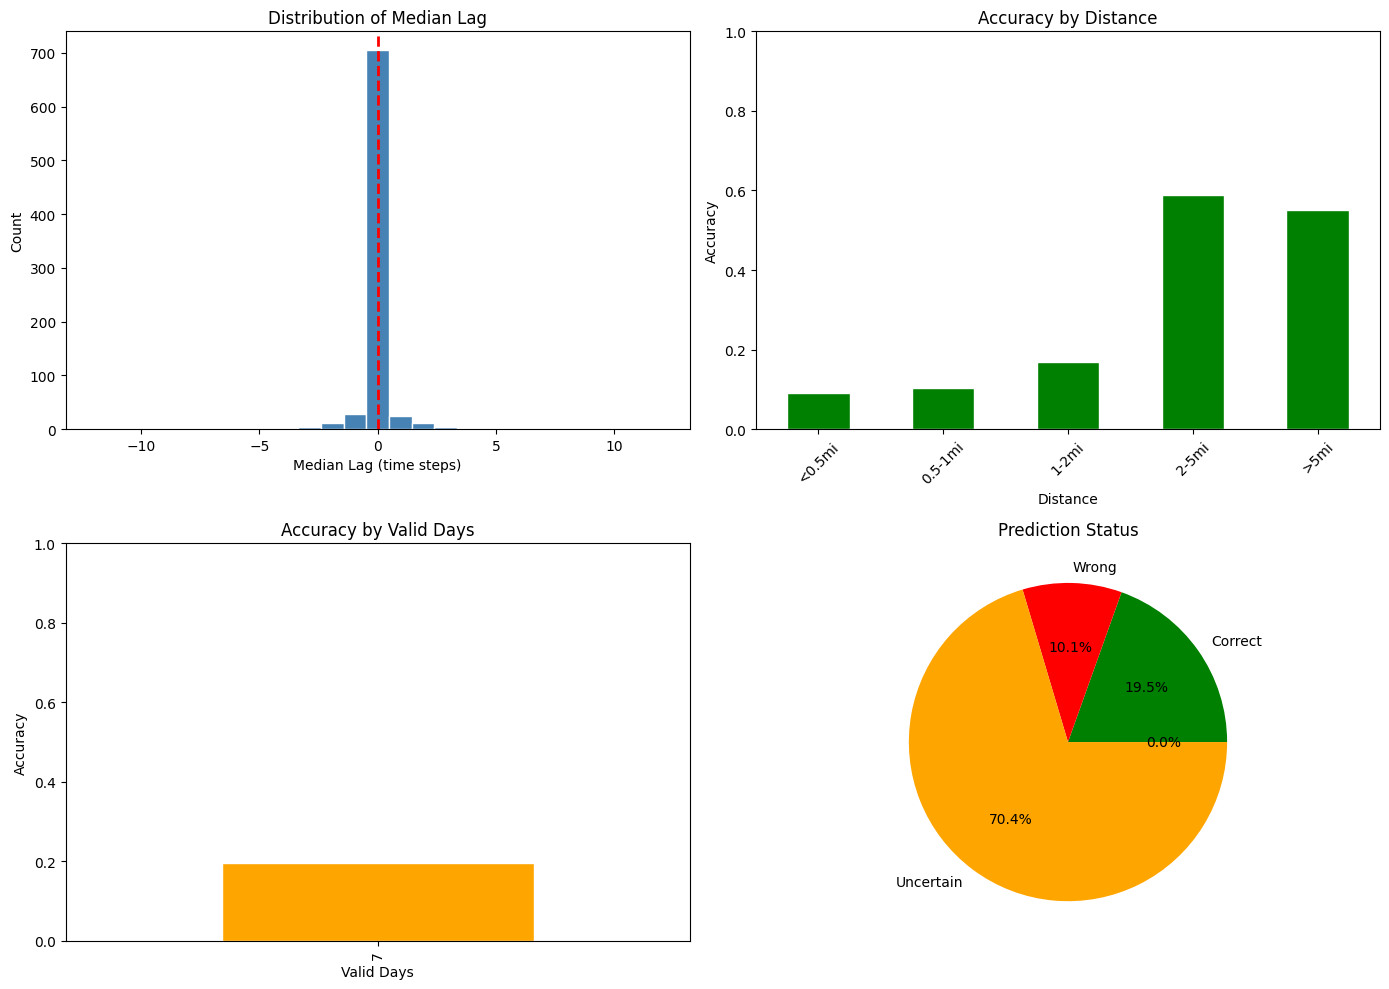

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 滞后分布
valid_median_lags = results_df['Median_Lag'].dropna()
axes[0, 0].hist(valid_median_lags, bins=25, color='steelblue', edgecolor='white')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Median Lag (time steps)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Median Lag')

# 2. 精度 vs 距离
dist_acc = results_df.groupby('Dist_Bin')['Correct'].mean()
dist_acc.plot(kind='bar', ax=axes[0, 1], color='green', edgecolor='white')
axes[0, 1].set_xlabel('Distance')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy by Distance')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
axes[0, 1].set_ylim(0, 1)

# 3. 精度 vs 有效天数
valid_day_acc = results_df.groupby('Valid_Days')['Correct'].mean()
valid_day_acc.plot(kind='bar', ax=axes[1, 0], color='orange', edgecolor='white')
axes[1, 0].set_xlabel('Valid Days')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy by Valid Days')
axes[1, 0].set_ylim(0, 1)

# 4. 预测结果分布
pred_counts = results_df['Pred_Source'].apply(
    lambda x: 'Correct' if x in results_df['True_Source'].values and results_df[results_df['Pred_Source']==x]['Correct'].any() else 
              ('Wrong' if x not in ['uncertain', 'unknown'] else x)
)
status_counts = pd.Series({
    'Correct': correct,
    'Wrong': len(valid) - valid['Correct'].sum(),
    'Uncertain': uncertain,
    'Unknown': unknown
})
status_counts.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', 
                   colors=['green', 'red', 'orange', 'gray'])
axes[1, 1].set_ylabel('')
axes[1, 1].set_title('Prediction Status')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'direction_inference_multiday.png'), dpi=150)
plt.show()

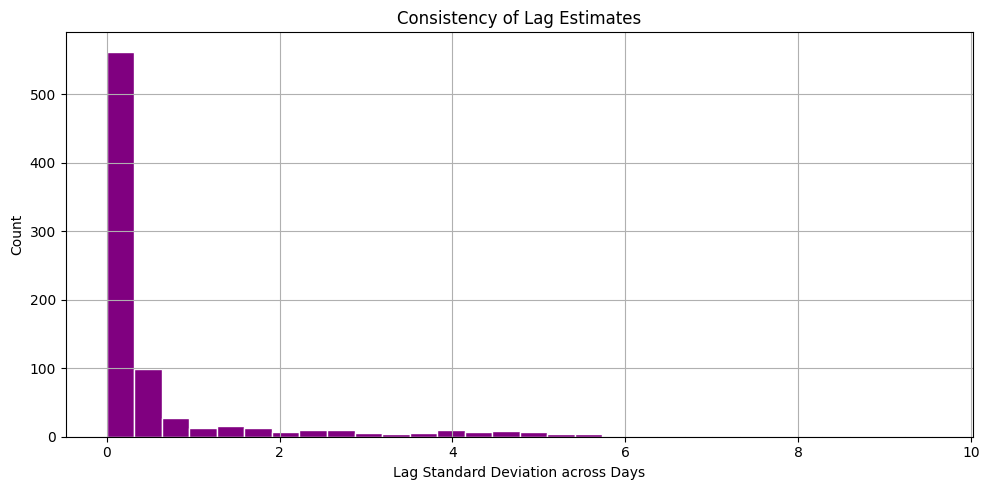

滞后标准差统计:
count    814.00
mean       0.55
std        1.29
min        0.00
25%        0.00
50%        0.00
75%        0.35
max        9.55
Name: Lag_Std, dtype: float64


In [20]:
# 查看每天滞后的一致性
lag_cols = [c for c in results_df.columns if c.startswith('Lag_') and c[4:].isdigit()]
lag_matrix = results_df[lag_cols].values

# 计算每对的滞后标准差
results_df['Lag_Std'] = np.nanstd(lag_matrix, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
results_df['Lag_Std'].dropna().hist(bins=30, ax=ax, color='purple', edgecolor='white')
ax.set_xlabel('Lag Standard Deviation across Days')
ax.set_ylabel('Count')
ax.set_title('Consistency of Lag Estimates')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lag_consistency_multiday.png'), dpi=150)
plt.show()

print("滞后标准差统计:")
print(results_df['Lag_Std'].describe().round(2))

In [21]:
# 查看一些具体案例
print("\n预测正确的案例:")
display(results_df[results_df['Correct']][['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 
                                            'Median_Lag', 'Valid_Days', 'Lag_Std']].head(10))

print("\n预测错误的案例:")
wrong = results_df[~results_df['Correct'] & ~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
display(wrong[['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 'Median_Lag', 
               'Valid_Days', 'True_Source', 'Pred_Source']].head(10))


预测正确的案例:


,Node1,Node2,Fwy,Dir,Distance,Median_Lag,Valid_Days,Lag_Std
5,3085044,3034034,113,S,5.024,-1.0,7,1.905952
6,3034034,3415047,113,S,28.255,-7.0,7,3.811904
7,3415047,3415044,113,S,0.049,0.0,7,0.349927
18,3413064,314521,160,N,36.372,7.0,7,2.602981
25,3022012,3085061,20,E,19.398,0.0,7,0.699854
26,3085061,3423018,20,E,26.306,1.0,7,1.484615
30,3422031,3422041,20,E,1.260,0.0,7,1.124858
31,3022021,3090052,20,W,2.721,-1.0,7,4.015277
32,3090052,3022011,20,W,9.245,-2.0,7,3.155817
38,3422032,3422081,20,W,1.085,0.0,7,0.451754



预测错误的案例:


,Node1,Node2,Fwy,Dir,Distance,Median_Lag,Valid_Days,True_Source,Pred_Source
2,316482,3415046,113,N,28.241,-1.0,7,316482,3415046
4,3034101,3085044,113,S,3.980,0.0,7,3085044,3034101
8,3010011,3413051,12,E,0.355,0.0,7,3010011,3413051
14,3010012,3413054,12,W,0.358,7.0,7,3413054,3010012
19,3413061,314580,160,S,36.370,1.0,7,314580,3413061
21,3069011,3410018,162,E,18.008,0.0,7,3069011,3410018
23,3022022,3090051,20,E,2.684,-2.0,7,3022022,3090051
27,3423018,3422011,20,E,1.294,-1.0,7,3423018,3422011
33,3022011,3085064,20,W,19.404,5.0,7,3085064,3022011
43,3029112,3029113,244,W,0.015,0.0,7,3029113,3029112


## 10. 保存结果

In [22]:
# 保存完整结果
output_path = os.path.join(OUTPUT_DIR, 'direction_inference_multiday.csv')
results_df.to_csv(output_path, index=False)
print(f"结果已保存: {output_path}")

# 保存摘要
summary = f"""
边方向推断结果摘要（多日投票版）
================================

配置:
- 使用指标: {METRIC}
- 最大滞后: {MAX_LAG} 步 ({MAX_LAG * 5} 分钟)
- 分析日期数: {len(selected_dates)}

分析日期:
{chr(10).join(str(d) for d in selected_dates)}

结果:
- 总传感器对数: {total}
- 有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)
- 不确定数: {uncertain} ({uncertain/total*100:.1f}%)
- 无数据数: {unknown} ({unknown/total*100:.1f}%)

精度:
- 整体精度: {correct/total*100:.1f}%
- 有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%

按方向:
{dir_stats.to_string()}

按距离:
{dist_stats.to_string()}
"""

with open(os.path.join(OUTPUT_DIR, 'direction_inference_multiday_summary.txt'), 'w') as f:
    f.write(summary)
print(f"摘要已保存: direction_inference_multiday_summary.txt")

结果已保存: ../output/edge_inference/direction_inference_multiday.csv
摘要已保存: direction_inference_multiday_summary.txt


---
## 说明

### 方法
1. 选择多个日期（默认每月一个周二）
2. 每个日期独立计算互相关滞后
3. 多日投票决定方向（>60%一致才确定）

### 输出文件
| 文件 | 说明 |
|------|------|
| `direction_inference_multiday.csv` | 完整结果 |
| `direction_inference_multiday_summary.txt` | 精度摘要 |
| `direction_inference_multiday.png` | 统计图 |

### 可调参数
- `METRIC`: 使用的指标（Total_Flow / Avg_Speed / Avg_Occupancy）
- `MAX_LAG`: 最大滞后范围
- `selected_dates`: 分析的日期列表
- 投票阈值（当前 60%）